In [12]:
from pachner_traversal.utils import data_root
import pandas as pd
import matplotlib.pyplot as plt
import regina
import numpy as np

In [13]:
def check_closed(iso_sig):
    try:
        T = regina.engine.Triangulation3.rehydrate(iso_sig)
        closed = T.isClosed()
    except:
        closed = False

    return closed

In [14]:
res_path = data_root / "results" / "sgd_models_dehydration" / "scale"

In [15]:
models = [
    "spheres_1024emb_24block_8head_10tet",
    "spheres_512emb_6block_4head_10tet",
    "spheres_768emb_12block_6head_10tet",
    "spheres_1536emb_32block_12head_10tet",
    "spheres_256emb_4block_4head_10tet"
]

flops_map = {
    "spheres_1024emb_24block_8head_10tet": 302_452_736,
    "spheres_768emb_12block_6head_10tet": 85_161_984,
    "spheres_512emb_6block_4head_10tet": 18_985_984,
    "spheres_256emb_4block_4head_10tet": 3_194_880,
}

In [16]:
for model in models:
    try:
        p = res_path / model
    except:
        pass

In [6]:
p_closed = {}

for model in models:
    p = res_path / model
    data = {}
    for f in p.iterdir():
        if f.name.startswith('gen') and f.name != 'generated_samples.txt':
            n_itts = f.name.split('_')[-1]
            n_itts = n_itts.split('.')[0]
            n_itts = n_itts.replace(',', '')
            n_itts = int(n_itts)

            if n_itts % 10 == 9:
                n_itts = n_itts + 1

            n_flops = n_itts * flops_map[model]


            with open(f, "r") as f:
                lines = f.readlines()

            closed = []

            samps_str = [line.strip() for line in lines]
            for i, iso in enumerate(samps_str):
                closed.append(check_closed(iso))
            data[n_flops] = np.mean(closed)

    p_closed[model] = pd.Series(data).sort_index()

In [22]:
train_losses = {}
test_losses = {}

for model in models:
    try:
        p = res_path / model / "train_losses.csv"
        data = pd.read_csv(p, index_col=0, header=None)[1]
        data.index.name = None
        data.index = data.index * flops_map[model]
        train_losses[model] = data

        p = res_path / model / "test_losses.csv"
        data = pd.read_csv(p, index_col=0, header=None)[1]
        data.index.name = None
        data.index = data.index * flops_map[model]
        test_losses[model] = data
    except:
        pass

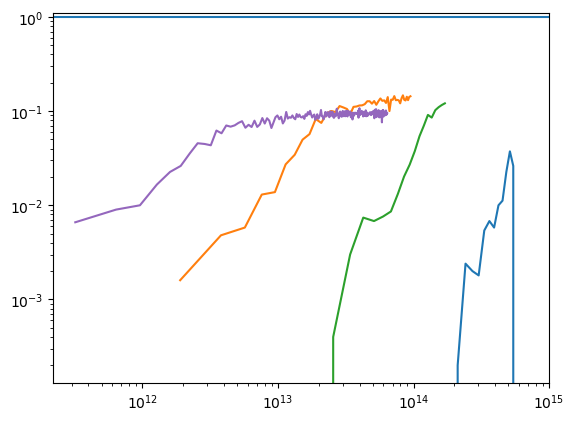

In [8]:
for model in models:
    try:
        plt.plot(p_closed[model])
    except:
        pass

plt.axhline(1)

plt.loglog()
plt.xlim([None, 1e15])
plt.ylim([None, 1.1])
plt.show()

In [ ]:
test_losses

In [11]:
for model in models:
    print(len(test_losses[model]))

200
500
200


KeyError: 'spheres_1536emb_32block_12head_10tet'

/tmp/ipykernel_14723/1618737234.py:8: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0, 1e15])


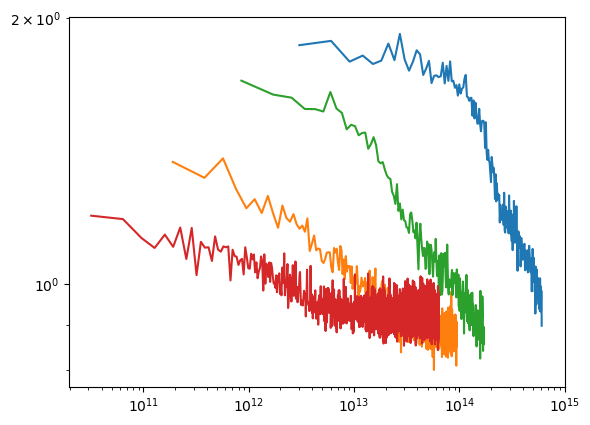

In [23]:
for model in models:
    try:
        plt.plot(train_losses[model])
    except:
        pass

plt.loglog()
plt.xlim([0, 1e15])
plt.show()